# Temat: Wyciągnięcie informacji z obrazu o bananie
Paul Paczyński
Weronika Ramutkowska 107421

Grupa SiUM_2m M

## 1. Konfiguracja środowiska i ścieżek
W tej sekcji importujemy niezbędne biblioteki (OpenCV, skimage, NumPy, Matplotlib) oraz definiujemy kluczowe stałe.

Pracujemy na datasecie https://www.kaggle.com/datasets/shahriar26s/banana-ripeness-classification-dataset, który zawiera w swojej oryginalnej formie klasy:
* **Unripe** (Niedojrzałe)
* **Ripe** (Dojrzałe)
* **Overripe** (Przejrzałe)
* **Rotten** (Zgniłe)

lecz my korzystamy tylko z 3 pierwszych klas
* **Unripe** (2179 zdjęć)
* **Ripe** (4015 zdjęć)
* **Overripe** (2691 zdjęć)


In [12]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
import random

from skimage.feature import graycomatrix, graycoprops
import sys
import concurrent.futures
import math

In [13]:
# --- KONFIGURACJA ŚCIEŻEK ---
POSSIBLE_PATHS = [
    os.path.abspath('Assets/bananadataset/dataset/data'),
    os.path.abspath('bananadataset/dataset/data'),
    os.path.abspath('./data')
]
BASE_PATH = next((p for p in POSSIBLE_PATHS if os.path.exists(p)), None)

# --- KONFIGURACJA WYNIKÓW ---
RESULTS_DIR = 'wyniki'
if not os.path.exists(RESULTS_DIR):
    os.makedirs(RESULTS_DIR)
    print(f"Utworzono nowy folder na wyniki: {RESULTS_DIR}")
else:
    print(f"Folder wyników już istnieje: {RESULTS_DIR}")

if BASE_PATH:
    print(f"Baza danych: {BASE_PATH}")
else:
    print("Nie znaleziono folderu z danymi")

CATEGORIES = ['unripe', 'ripe', 'overripe']
SPLITS = ['train', 'test', 'valid']
VIS_LIMIT = 50

Folder wyników już istnieje: wyniki
Baza danych: G:\pycharm\BananaProject\Assets\bananadataset\dataset\data


## 2. Przykłady z datasetu

In [16]:
def show_sample_grid():
    if not BASE_PATH:
        print("Brak zdefiniowanej ścieżki BASE_PATH.")
        return

    rows, cols = 3, 5
    fig, axes = plt.subplots(rows, cols, figsize=(15, 9))
    fig.suptitle('Losowe próbki z każdej klasy (Train/Test/Valid)', fontsize=16, fontweight='bold', y=0.98)

    for i, category in enumerate(CATEGORIES):
        all_files = []
        for split in SPLITS:
            path = os.path.join(BASE_PATH, split, category)
            if os.path.exists(path):
                files = [os.path.join(path, f) for f in os.listdir(path)
                         if f.lower().endswith(('.jpg', '.png', '.jpeg', '.bmp'))]
                all_files.extend(files)

        selected = random.sample(all_files, min(len(all_files), cols)) if all_files else []

        for j in range(cols):
            ax = axes[i, j]

            if j < len(selected):
                img = cv2.imread(selected[j])
                if img is not None:
                    ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
                else:
                    ax.text(0.5, 0.5, "Błąd odczytu", ha='center')
            else:
                ax.axis('off')

            ax.set_xticks([])
            ax.set_yticks([])

            if j == 0:
                ax.set_ylabel(category.upper(), fontsize=14, fontweight='bold', labelpad=10)

    plt.tight_layout()
    plt.show()


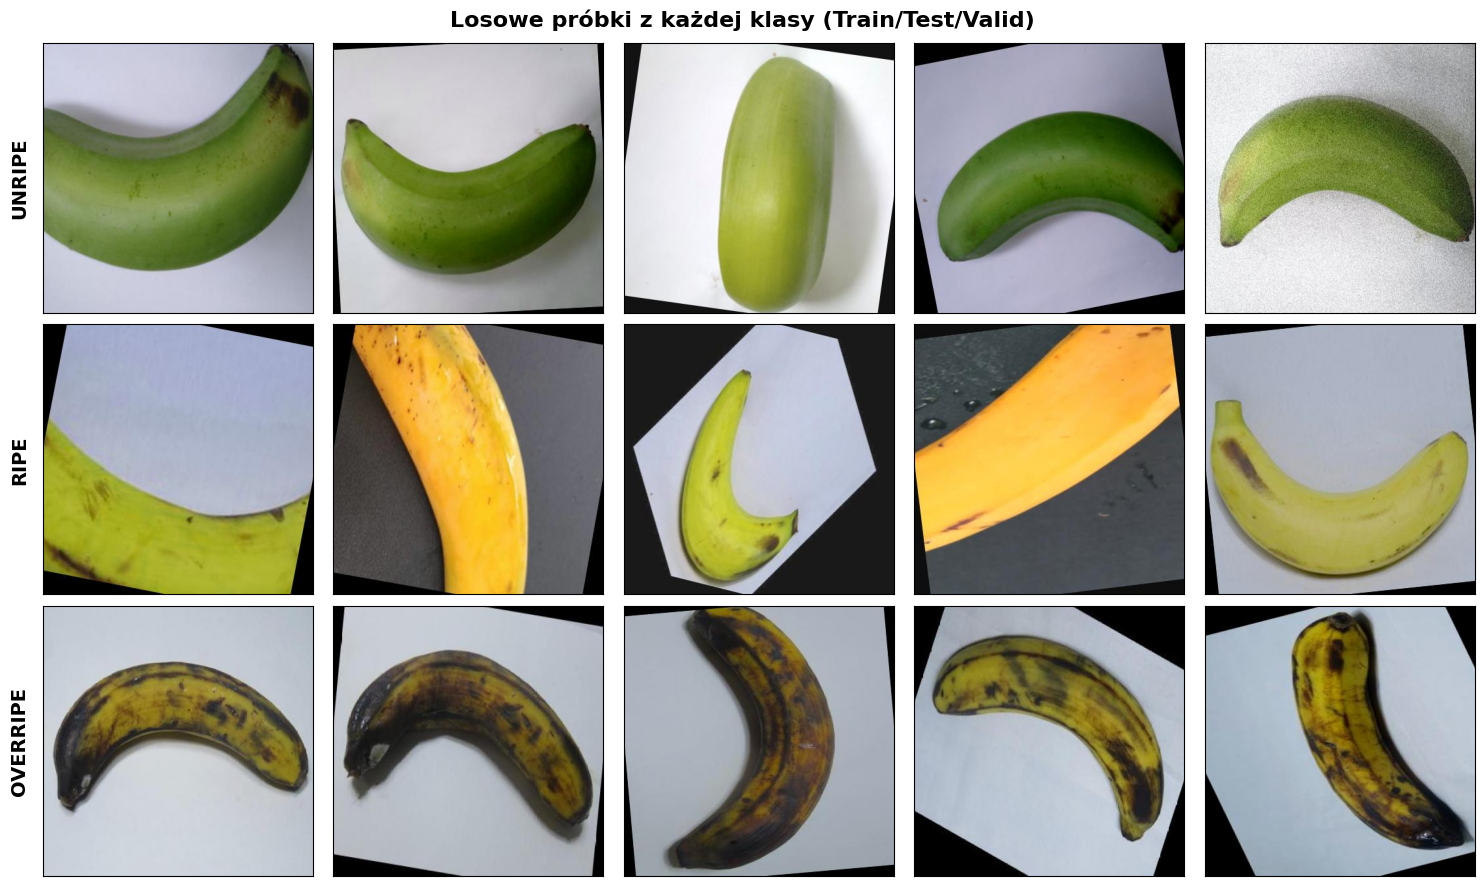

In [17]:
show_sample_grid()

# 3. Analiza jasności (Grayscale Histogram)
Ta funkcja analizuje rozkład jasności pikseli dla każdej kategorii (unripe, overripe i ripe).
Dzięki temu otrzymujemy trzy uśrednione linie reprezentujące ogólną charakterystykę jasności dla:
* **Unripe** (Niedojrzałe)
* **Ripe** (Dojrzałe)
* **Overripe** (Przejrzałe)

Wynik jest zapisywany jako `analiza_jasnosci_histogram.png`.

In [9]:
def process_folders_in_batches(base_path, batch_size=100):
    valid_extensions = ('.png', '.jpg', '.jpeg', '.bmp', '.tiff')

    category_map = {cat: [] for cat in CATEGORIES}

    print("Skanowanie i grupowanie plików...")
    for root, _, files in os.walk(base_path):
        folder_name = os.path.basename(root)
        if folder_name in CATEGORIES:
            images = [os.path.join(root, f) for f in files if f.lower().endswith(valid_extensions)]
            category_map[folder_name].extend(images)

    if not any(category_map.values()):
        print("Nie znaleziono zdjęć w zdefiniowanych kategoriach.")
        return

    results = {}
    plt.figure(figsize=(12, 8))

    for category, image_list in category_map.items():
        total_in_cat = len(image_list)
        if total_in_cat == 0: continue

        print(f"Przetwarzanie zgrupowanej kategorii: {category.upper()} ({total_in_cat} zdjęć)")

        avg_hist = np.zeros((256, 1), dtype=np.float64)
        processed_count = 0

        for i in range(0, total_in_cat, batch_size):
            batch = image_list[i: i + batch_size]
            for path in batch:
                img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
                if img is None: continue

                hist = cv2.calcHist([img], [0], None, [256], [0, 256])
                hist = hist / img.size

                processed_count += 1
                avg_hist += (hist - avg_hist) / processed_count

        results[category] = avg_hist
        plt.plot(avg_hist, label=category, linewidth=2)
        plt.fill_between(range(256), avg_hist.flatten(), alpha=0.1)

    plt.title(f'Średnie histogramy jasności (Zgrupowane)')
    plt.xlabel('Jasność (0-255)')
    plt.ylabel('Częstość')
    plt.legend()
    plt.grid(True, alpha=0.3)

    save_path = os.path.join(RESULTS_DIR, 'analiza_jasnosci_histogram.png')
    plt.savefig(save_path)
    print(f"💾 Zapisano: {save_path}")
    plt.show()

Skanowanie i grupowanie plików...
Przetwarzanie zgrupowanej kategorii: UNRIPE (2179 zdjęć)
Przetwarzanie zgrupowanej kategorii: RIPE (4015 zdjęć)
Przetwarzanie zgrupowanej kategorii: OVERRIPE (2691 zdjęć)
💾 Zapisano: wyniki\analiza_jasnosci_histogram.png


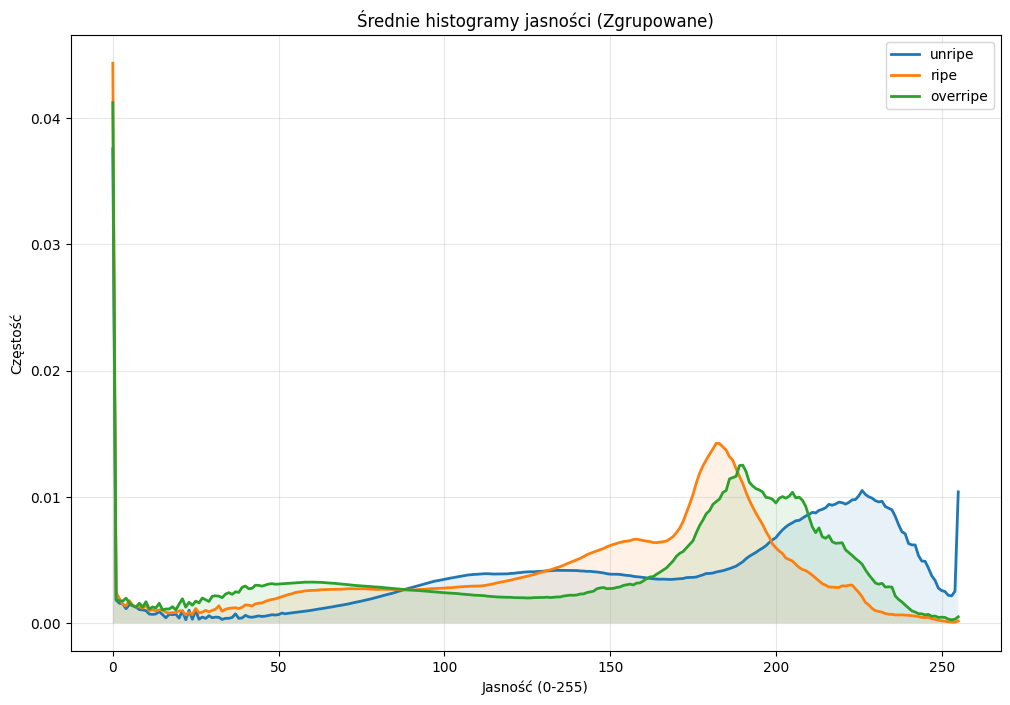

In [14]:
    process_folders_in_batches(BASE_PATH, batch_size=200)

## 4. Analiza hsv

W tej sekcji przeprowadzamy analizę w przestrzeni barw **HSV** (Hue, Saturation, Value).

Podobnie jak przy analizie jasności, skrypt grupuje zdjęcia ze wszystkich podfolderów (train, test, valid) dla danej kategorii, aby uzyskać pełny obraz.
Generowane są trzy wykresy ustawione w pionie:
1.  **Hue (Barwa):** Oś X (0-180) reprezentuje koło barw. Tło na wykresie pomaga wzrokowo ocenić, czy "górki" (piki) danych przypadają na kolor zielony (niedojrzałe), żółty (dojrzałe) czy pomarańczowo-brązowy (przejrzałe).
2.  **Saturation (Nasycenie):** Mówi o tym, jak intensywny jest kolor.
3.  **Value (Jasność):** Rozkład jasności barwy (podobnie jak wyżej).

Wynik jest zapisywany w pliku: `analiza_kolorow_hsv.png`.

In [10]:
def process_full_hsv_analysis(base_path, batch_size=100):
    category_map = {cat: [] for cat in CATEGORIES}

    for root, _, files in os.walk(base_path):
        folder_name = os.path.basename(root)
        if folder_name in CATEGORIES:
            images = [os.path.join(root, f) for f in files if f.lower().endswith(('.jpg', '.png'))]
            category_map[folder_name].extend(images)

    results = {}

    for category, image_list in category_map.items():
        total_in_cat = len(image_list)
        if total_in_cat == 0: continue

        print(f"Analiza HSV dla: {category.upper()}")

        h_avg, s_avg, v_avg = np.zeros((180, 1)), np.zeros((256, 1)), np.zeros((256, 1))
        count = 0

        for i in range(0, total_in_cat, batch_size):
            batch = image_list[i: i + batch_size]
            for path in batch:
                img = cv2.imread(path)
                if img is None: continue

                hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
                count += 1

                h_avg += (cv2.calcHist([hsv], [0], None, [180], [0, 180])/img.size - h_avg)/count
                s_avg += (cv2.calcHist([hsv], [1], None, [256], [0, 256])/img.size - s_avg)/count
                v_avg += (cv2.calcHist([hsv], [2], None, [256], [0, 256])/img.size - v_avg)/count

        results[category] = {'h': h_avg, 's': s_avg, 'v': v_avg}

    fig, axes = plt.subplots(3, 1, figsize=(12, 12))
    titles = ['Barwa (Hue)', 'Nasycenie (Saturation)', 'Jasność (Value)']
    keys = ['h', 's', 'v']
    limits = [180, 255, 255]

    for i, ax in enumerate(axes):
        for name, data in results.items():
            ax.plot(data[keys[i]], label=name, linewidth=2)
        ax.set_title(titles[i])
        ax.set_xlim(0, limits[i])
        ax.legend()
        ax.grid(alpha=0.3)
        if i == 0:
             for j in range(180):
                ax.axvspan(j, j+1, color=plt.cm.hsv(j/180.0), alpha=0.1)

    plt.tight_layout()

    save_path = os.path.join(RESULTS_DIR, 'analiza_kolorow_hsv.png')
    plt.savefig(save_path)
    print(f"💾 Zapisano: {save_path}")
    plt.show()

Analiza HSV dla: UNRIPE
Analiza HSV dla: RIPE
Analiza HSV dla: OVERRIPE
💾 Zapisano: wyniki\analiza_kolorow_hsv.png


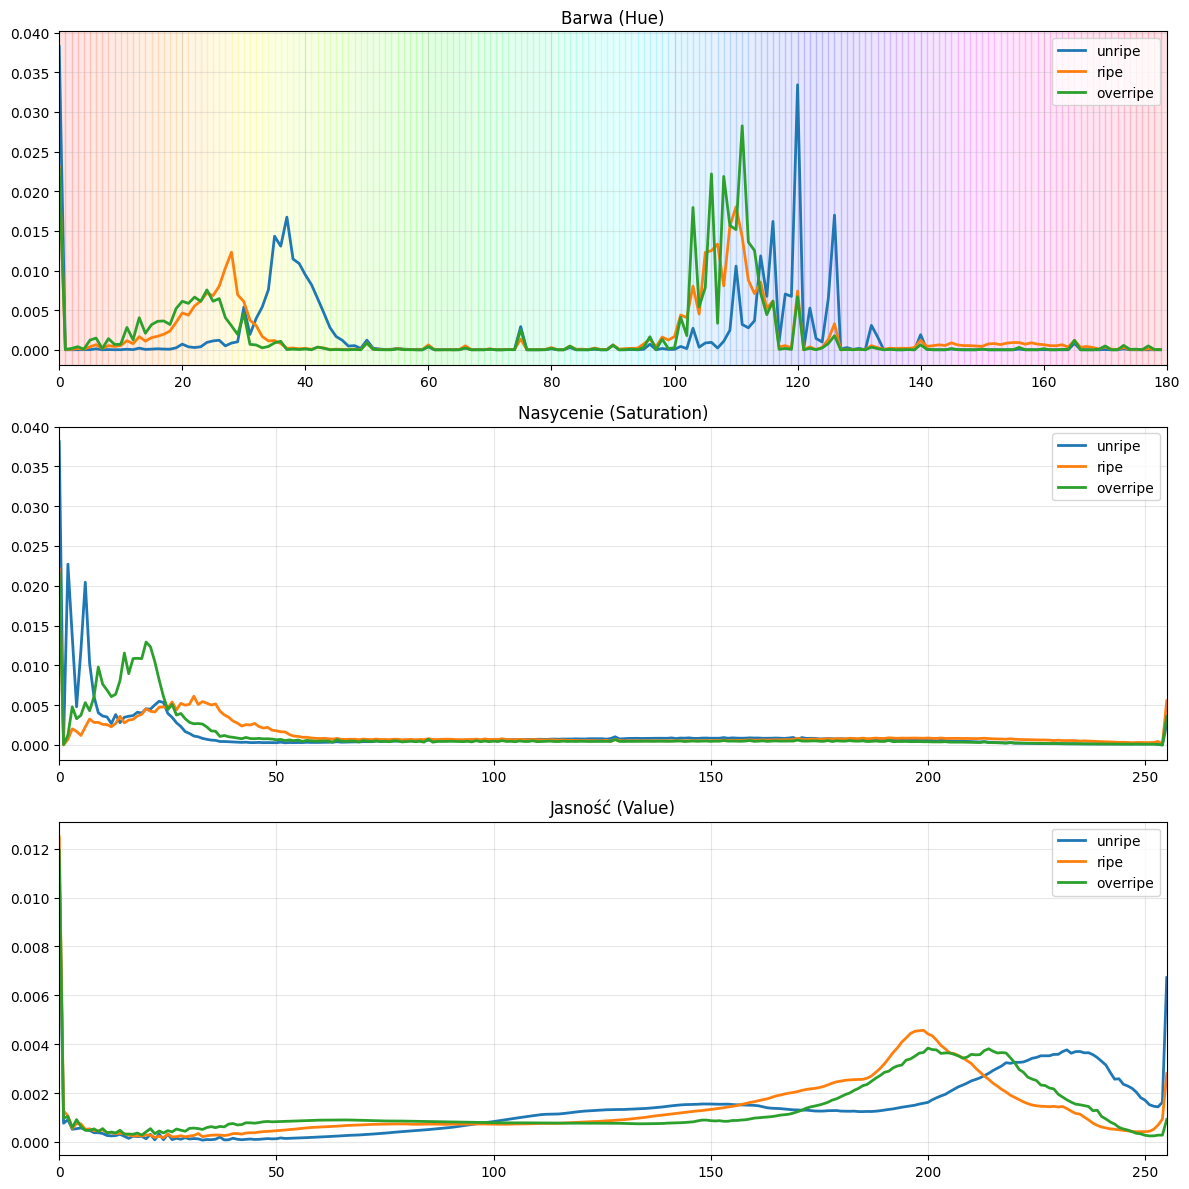

In [15]:
process_full_hsv_analysis(BASE_PATH, batch_size=200)

## 5. Kmeans na kanale H+S

Kombinacja kanałów Hue i Saturation w algorytmie K-Means okazała się najskuteczniejsza, ponieważ pozwala na (zazwyczaj) precyzyjne oddzielenie banana od tła przy jednoczesnym ignorowaniu zakłóceń wynikających z cieni i odblasków świetlnych. Działanie poniższej komórki prezentuje się nastepująco:

* K-Means dzieli piksele obrazu na dwa zbiory (klastry): "Tło" i "Obiekt".
* Skrypt automatycznie wykrywa, który zbiór to banan, sprawdzając średnie nasycenie (banan jest zazwyczaj bardziej "kolorowy" niż tło).
* Na końcu maska jest czyszczona (operacje morfologiczne) i wybierany jest największy obiekt (kontur), aby usunąć drobne śmieci z tła.

In [26]:
# --- SEGMENTACJA: K-MEANS (HUE + SATURATION) ---
def get_mask_kmeans_hs(img):
    try:
        hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
        h_channel = hsv[:, :, 0]
        s_channel = hsv[:, :, 1]
        features = np.dstack((h_channel, s_channel)).reshape((-1, 2)).astype(np.float32)
        criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 10, 1.0)
        _, labels, _ = cv2.kmeans(features, 2, None, criteria, 10, cv2.KMEANS_RANDOM_CENTERS)
        mask = labels.reshape(img.shape[:2]).astype(np.uint8) * 255

        if np.mean(s_channel[mask == 0]) > np.mean(s_channel[mask == 255]): #Tutaj sprawdzamy nasycenie
            mask = cv2.bitwise_not(mask)

        kernel = np.ones((5, 5), np.uint8)
        mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
        mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)

        contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        if contours:
            c = max(contours, key=cv2.contourArea)
            clean_mask = np.zeros_like(mask)
            cv2.drawContours(clean_mask, [c], -1, 255, thickness=cv2.FILLED)
            return clean_mask
        return mask
    except: return None


In [27]:
# --- WIZUALIZACJA NA PIERWSZYCH PRÓBKACH ---
def test_segmentation_samples():
    if not BASE_PATH:
        print("Brak BASE_PATH.")
        return

    fig, axes = plt.subplots(3, 2, figsize=(10, 12))
    fig.suptitle('Test segmentacji: Pierwsze zdjęcie z każdej klasy', fontsize=16, fontweight='bold')

    for i, category in enumerate(CATEGORIES):
        img_path = None
        found_split = ""

        for split in SPLITS:
            folder = os.path.join(BASE_PATH, split, category)
            if os.path.exists(folder):
                files = sorted([f for f in os.listdir(folder) if f.lower().endswith(('.jpg', '.png'))])
                if files:
                    img_path = os.path.join(folder, files[0]) # Bierzemy indeks 0 (pierwsze)
                    found_split = split
                    break

        ax_orig = axes[i, 0]
        ax_mask = axes[i, 1]

        if img_path:
            img = cv2.imread(img_path)
            mask = get_mask_kmeans_hs(img)

            ax_orig.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
            ax_orig.set_title(f"{category.upper()} (Co wchodzi na algorytm)")

            if mask is not None:
                ax_mask.imshow(mask, cmap='gray')
                ax_mask.set_title("Maska (K-Means H+S)")
            else:
                ax_mask.text(0.5, 0.5, "Błąd generowania maski", ha='center')
        else:
            ax_orig.text(0.5, 0.5, "Brak zdjęć", ha='center')
            ax_mask.axis('off')

        ax_orig.axis('off')
        ax_mask.axis('off')

    plt.tight_layout()
    plt.show()

### Wizualizacja

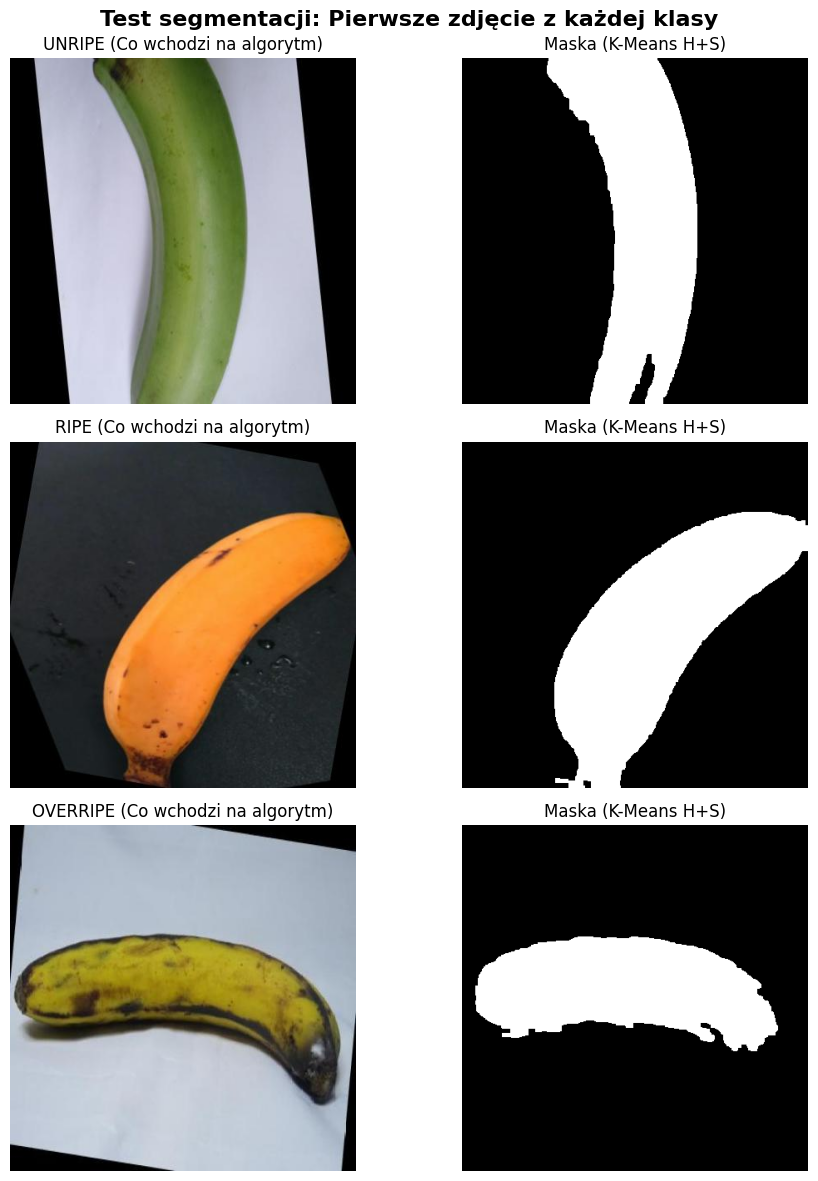

In [28]:
test_segmentation_samples()

Powyżej jesteśmy w stanie zaobserwować działanie algorytmu tworzenia maski.

## 6. Ekstrakcja cech tekstury (GLCM)
W tej sekcji wyliczamy parametry statystyczne tekstury skórki banana przy użyciu macierzy współwystępowania poziomów szarości (**GLCM**).
Analizujemy cztery kluczowe cechy:
* **Contrast** (Kontrast): różnorodność lokalna.
* **Correlation** (Korelacja): liniowe zależności jasności.
* **Energy** (Energia): jednolitość obrazu.
* **Homogeneity** (Jednorodność): bliskość rozkładu do przekątnej macierzy GLCM.

Wyświetlamy również **Heatmapę GLCM**, która wizualizuje strukturę tekstury w formie matematycznej gęstości prawdopodobieństwa.

In [29]:
# --- CECHY GLCM ---
def calculate_features(img, mask):
    try:
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        masked_gray = cv2.bitwise_and(gray, gray, mask=mask)
        glcm = graycomatrix(masked_gray, [1], [0, np.pi/4, np.pi/2, 3*np.pi/4], levels=256, symmetric=True, normed=True)
        glcm[0,:,:,:] = 0; glcm[:,0,:,:] = 0
        if np.sum(glcm) > 0: glcm /= np.sum(glcm)

        feats = {
            "Contrast": np.mean(graycoprops(glcm, 'contrast')),
            "Correlation": np.mean(graycoprops(glcm, 'correlation')),
            "Energy": np.mean(graycoprops(glcm, 'energy')),
            "Homogeneity": np.mean(graycoprops(glcm, 'homogeneity'))
        }
        viz = np.log(np.mean(glcm, axis=(2, 3)) + 1e-9)
        return feats, masked_gray, viz
    except: return None, None, None

### Wizualizacja

In [33]:
# --- WIZUALIZACJA DLA JEDNEGO ZDJĘCIA Z KAŻDEJ KLASY ---
def show_glcm_test():
    if not BASE_PATH:
        print("Brak BASE_PATH")
        return

    # 3 wiersze (klasy) x 3 kolumny (Oryginał, Maska, GLCM Heatmap)
    fig, axes = plt.subplots(3, 3, figsize=(15, 12))
    fig.suptitle('Analiza Tekstury GLCM: Próbki z każdej klasy', fontsize=16, fontweight='bold')

    for i, category in enumerate(CATEGORIES):
        img_path = None
        for split in SPLITS:
            folder = os.path.join(BASE_PATH, split, category)
            if os.path.exists(folder):
                files = sorted([f for f in os.listdir(folder) if f.lower().endswith(('.jpg', '.png'))])
                if files:
                    img_path = os.path.join(folder, files[0])
                    break

        if img_path:
            img = cv2.imread(img_path)
            mask = get_mask_kmeans_hs(img)
            feats, masked_gray, viz = calculate_features(img, mask)

            # 1. Oryginał
            axes[i, 0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
            axes[i, 0].set_title(f"{category.upper()}")

            # 2. Wycięty banan (Grayscale)
            axes[i, 1].imshow(masked_gray, cmap='gray')
            axes[i, 1].set_title("Wycięty obiekt (Input GLCM)")

            # 3. Heatmapa GLCM + Wypisanie KOMPLETU cech
            if viz is not None:
                axes[i, 2].imshow(viz, cmap='viridis')
                axes[i, 2].set_title("Heatmapa GLCM")

                # Dodanie tekstu ze wszystkimi 4 cechami
                txt = (f"Contrast: {feats['Contrast']:.1f}\n"
                       f"Correlation: {feats['Correlation']:.3f}\n"
                       f"Energy: {feats['Energy']:.3f}\n"
                       f"Homogeneity: {feats['Homogeneity']:.2f}")

                # Wyświetlenie tekstu obok wykresu
                axes[i, 2].text(270, 128, txt, fontsize=11, va='center',
                               fontweight='bold', color='darkblue',
                               bbox=dict(facecolor='white', alpha=0.7))

        for ax in axes[i]: ax.axis('off')

    plt.tight_layout()
    plt.show()

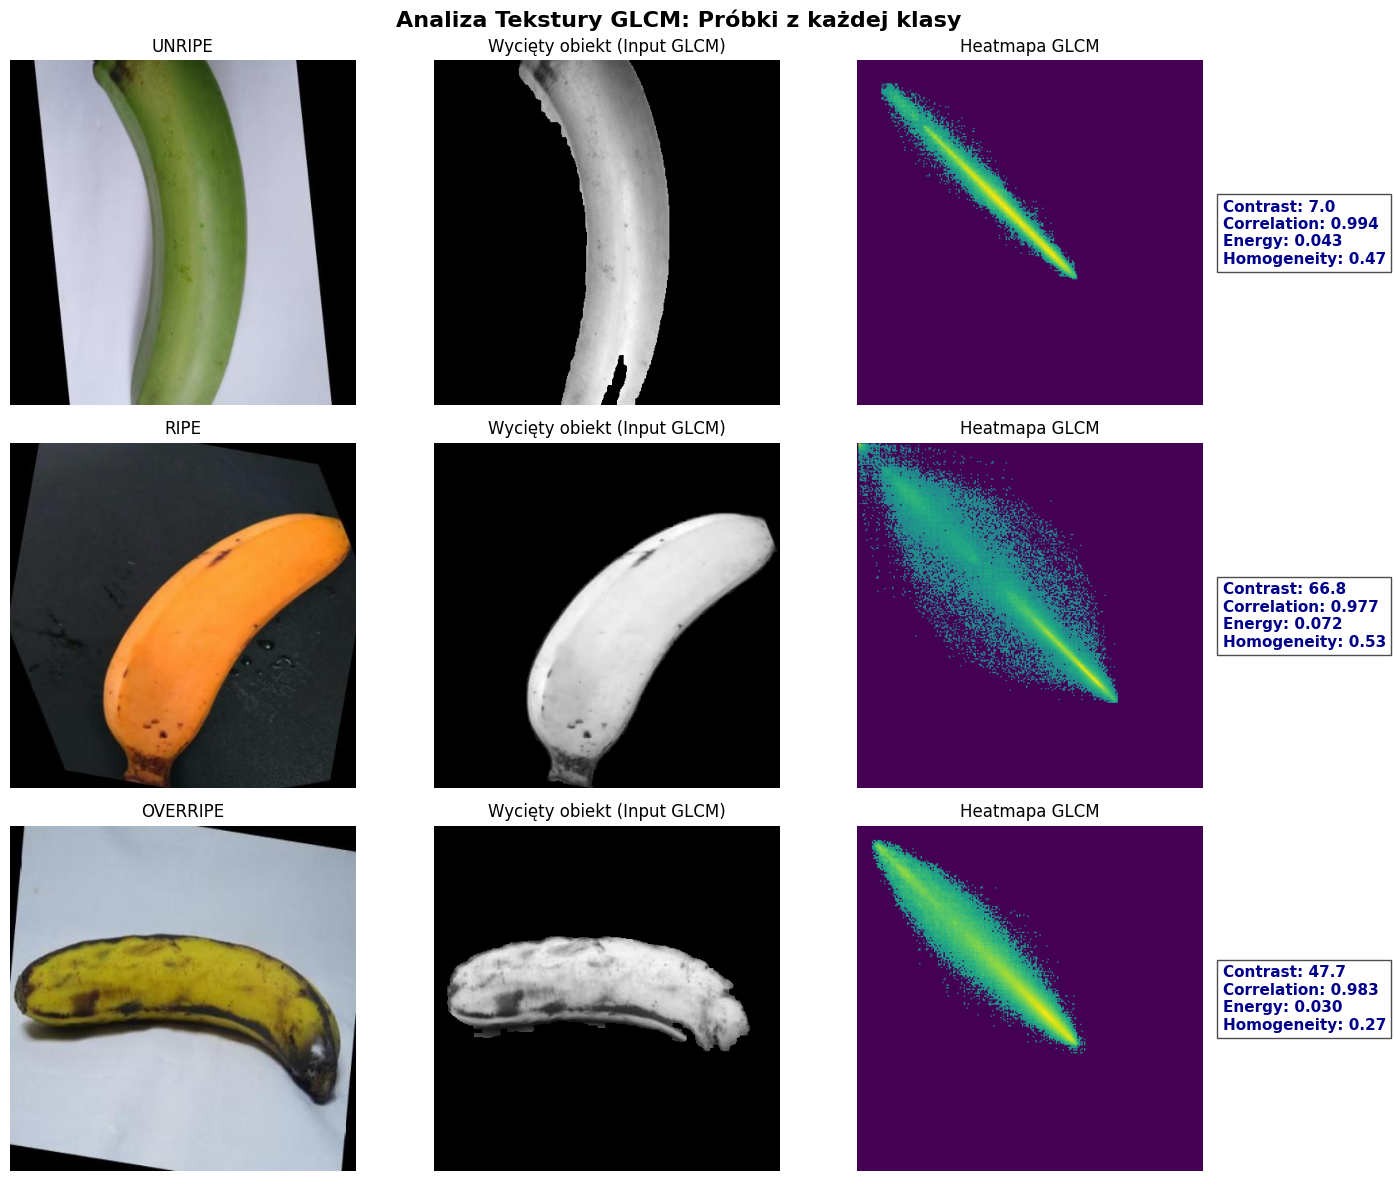

In [34]:
show_glcm_test()

## 7. Przetważanie i wizualizacja zbiorcza

Ta sekcja odpowiada za generowanie raportu wizualno-statystycznego dla każdej klasy dojrzałości, łącząc podgląd procesu segmentacji z analizą rozkładu cech tekstury. Funkcja calculate_outliers_count identyfikuje anomalie w zbiorze przy użyciu metody rozstępu międzykwartylowego (IQR), co pozwala ocenić czystość danych i jakość ekstrakcji cech. Na dashboardzie prezentowane są histogramy dla parametrów Contrast, Correlation, Energy i Homogeneity, wraz z wyliczoną średnią, co umożliwia bezpośrednie porównanie charakterystyki skórki bananów w różnych stadiach.

In [36]:
def calculate_outliers_count(data):
    if not data: return 0
    q1, q3 = np.percentile(data, [25, 75])
    iqr = q3 - q1
    return len([x for x in data if x < q1 - 1.5*iqr or x > q3 + 1.5*iqr])

def plot_category_dashboard(category, stats, sample_data):
    if sample_data is None: return
    img, final_mask, input_glcm, heatmap, info_txt = sample_data

    fig = plt.figure(figsize=(16, 10))
    fig.suptitle(f"STATYSTYKI: {category.upper()}", fontsize=18, fontweight='bold', color='darkblue')

    ax1 = fig.add_subplot(3, 4, 1); ax1.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)); ax1.set_title("Oryginał")
    ax2 = fig.add_subplot(3, 4, 2); ax2.imshow(final_mask, cmap='gray'); ax2.set_title(f"Maska\n{info_txt}", fontsize=9)
    ax3 = fig.add_subplot(3, 4, 3); ax3.imshow(input_glcm, cmap='gray'); ax3.set_title("Input GLCM")
    ax4 = fig.add_subplot(3, 4, 4); ax4.imshow(heatmap, cmap='viridis'); ax4.set_title("Heatmapa GLCM")

    ax_txt = fig.add_subplot(3, 4, 5); ax_txt.axis('off')
    n_samples = len(stats['Contrast'])
    txt = f"Liczba zdjęć: {n_samples}\nOUTLIERS:\n"
    for k, v in stats.items():
        cnt = calculate_outliers_count(v)
        perc = (cnt/n_samples*100) if n_samples > 0 else 0
        txt += f"{k}: {cnt} ({perc:.1f}%)\n"
    ax_txt.text(0, 0.5, txt, fontsize=12, va='center')

    metrics = ['Contrast', 'Correlation', 'Energy', 'Homogeneity']
    cols = ['#3498db', '#e74c3c', '#2ecc71', '#f1c40f']
    for i, m in enumerate(metrics):
        ax = fig.add_subplot(3, 4, 9+i)
        vals = stats[m]
        if vals:
            ax.hist(vals, bins=50, color=cols[i], edgecolor='black', alpha=0.7)
            ax.axvline(np.mean(vals), color='black', linestyle='--')
            ax.set_title(m)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])

    # --- ZAPIS ---
    filename = f"dashboard_{category}.png"
    plt.savefig(os.path.join(RESULTS_DIR, filename))
    print(f"Zapisano dashboard: {filename}")
    plt.show()

Ta funkcja generuje przejrzystą galerię miniaturek masek binarnych, pozwalając na szybką, wizualną weryfikację skuteczności segmentacji dla dużej liczby obrazów jednocześnie. Każda ramka galerii otrzymuje kolor odpowiadający danej klasie dojrzałości (zielony, złoty lub czerwony), co ułatwia organizację wyników. Dzięki takiemu zestawieniu można łatwo wykryć błędy algorytmu K-Means, takie jak niedokładne wycięcie krawędzi banana czy błędne zaklasyfikowanie tła.

In [37]:
def plot_mask_gallery(category, thumbnails):
    total = len(thumbnails)
    if total == 0: return
    cols = 10
    rows = math.ceil(total / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(20, rows * 1.5))
    fig.suptitle(f"GALERIA: {category.upper()} (Metoda Hue+Sat)", fontsize=16, fontweight='bold', y=1.0)
    axes_flat = axes.flatten() if total > 1 else [axes]
    col = {'unripe': 'green', 'ripe': 'gold', 'overripe': 'red'}.get(category, 'blue')

    for i, ax in enumerate(axes_flat):
        if i < total:
            ax.imshow(thumbnails[i], cmap='gray')
            for spine in ax.spines.values(): spine.set_edgecolor(col); spine.set_linewidth(2)
            ax.set_xticks([]); ax.set_yticks([])
        else: ax.axis('off')

    plt.tight_layout()

    # --- ZAPIS ---
    filename = f"galeria_masek_{category}.png"
    plt.savefig(os.path.join(RESULTS_DIR, filename))
    print(f"Zapisano galerię: {filename}")
    plt.show()


Ta funkcja generuje zestawienie porównawcze w formie wykresów pudełkowych (Boxplots), które pozwalają na statystyczną ocenę różnic między klasami dojrzałości dla wszystkich czterech cech tekstury jednocześnie. Skrypt umożliwia wygenerowanie dwóch wersji podsumowania – z uwzględnieniem wartości odstających oraz w wersji „czystej”, co ułatwia dostrzeżenie głównych trendów, takich jak spadek jednorodności czy wzrost kontrastu wraz z dojrzewaniem owoców. Dzięki zastosowaniu wcięć w pudełkach (parametr notch) oraz kolorystycznego wyróżnienia kategorii, możliwe jest szybkie określenie istotności różnic między grupami unripe, ripe i overripe.

In [40]:
def plot_final_comparison(all_data, show_outliers=True):
    title = 'Z OUTLIERAMI' if show_outliers else 'BEZ OUTLIERÓW'
    suffix = 'outliers' if show_outliers else 'clean'

    print(f"\n📊 Generowanie zestawienia {title}...")
    metrics = [('Contrast', '#3498db'), ('Homogeneity', '#f1c40f'),
               ('Correlation', '#e74c3c'), ('Energy', '#2ecc71')]

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle(f'PODSUMOWANIE ({title})', fontsize=16, fontweight='bold')
    axes = axes.flatten()
    box_colors = ['#ADD8E6', '#90EE90', '#FA8072']

    for idx, (metric, color) in enumerate(metrics):
        ax = axes[idx]
        data = [all_data[cat][metric] for cat in CATEGORIES]
        if not any(data): continue

        bplot = ax.boxplot(data, patch_artist=True, tick_labels=[c.upper() for c in CATEGORIES],
                           notch=True, showfliers=show_outliers)

        for patch, c in zip(bplot['boxes'], box_colors):
            patch.set_facecolor(c)

        ax.set_title(metric.upper(), fontweight='bold')
        ax.grid(axis='y', linestyle='--', alpha=0.5)

    plt.tight_layout(rect=[0, 0.03, 1, 0.97])

    # --- ZAPIS ---
    filename = f"podsumowanie_{suffix}.png"
    save_path = os.path.join(RESULTS_DIR, filename)
    plt.savefig(save_path)
    print(f"💾 Zapisano podsumowanie: {filename}")
    plt.show()

### 7.1. Główna petla
Wewnątrz pętli skrypt wykonuje pełną sekwencję operacji dla każdego zdjęcia: od segmentacji barwnej K-Means, przez ekstrakcję czterech cech tekstury GLCM, aż po gromadzenie próbek do wizualizacji. Na koniec każdej kategorii automatycznie generowane są dashboardy statystyczne oraz galerie masek, a cały proces kończy stworzenie zbiorczych wykresów porównawczych dla wszystkich klas dojrzałości.


KATEGORIA: UNRIPE
   -> train/unripe: 1902 plików...
   -> test/unripe: 110 plików...
   -> valid/unripe: 167 plików...
Zakończono UNRIPE.
💾 Zapisano dashboard: dashboard_unripe.png


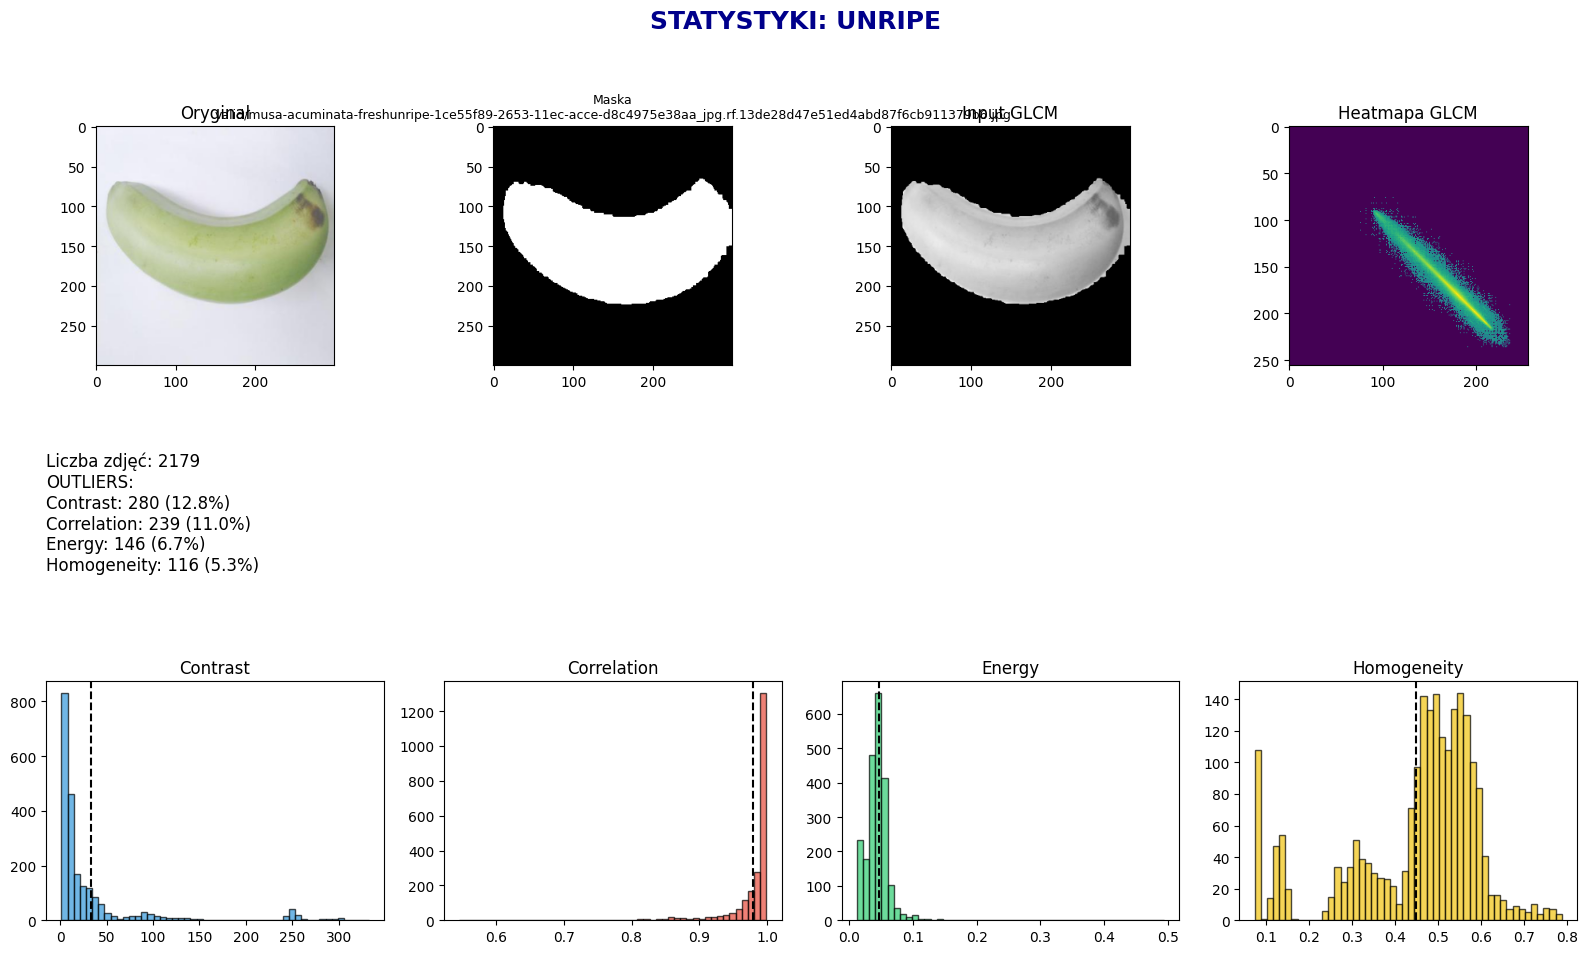

💾 Zapisano galerię: galeria_masek_unripe.png


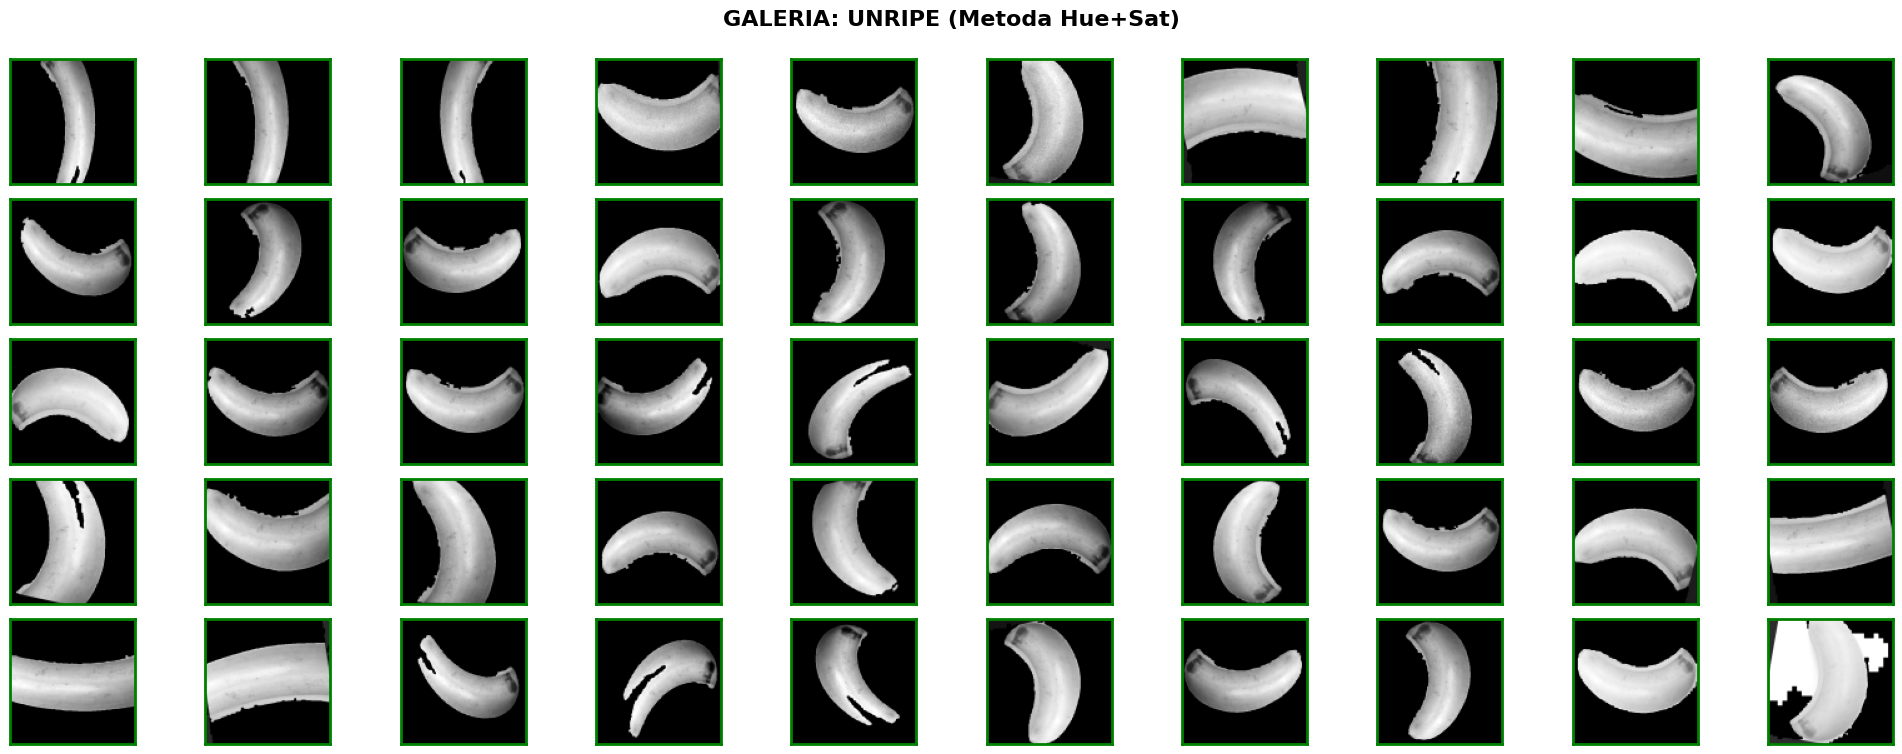


KATEGORIA: RIPE
   -> train/ripe: 3522 plików...
   -> test/ripe: 154 plików...
   -> valid/ripe: 339 plików...
Zakończono RIPE.
💾 Zapisano dashboard: dashboard_ripe.png


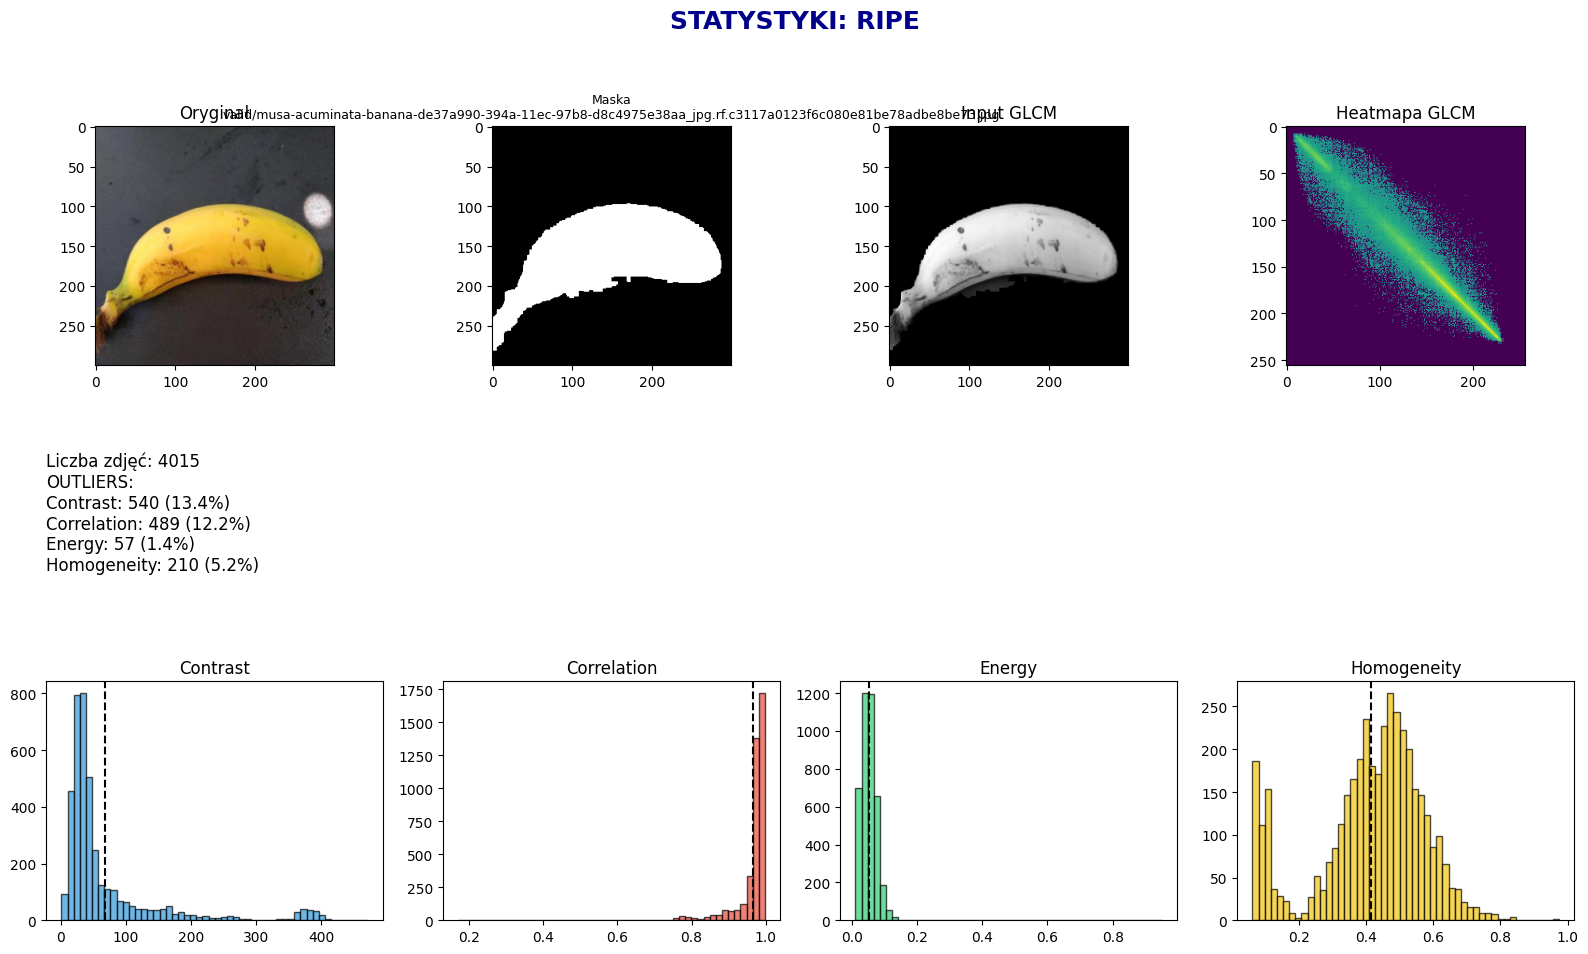

💾 Zapisano galerię: galeria_masek_ripe.png


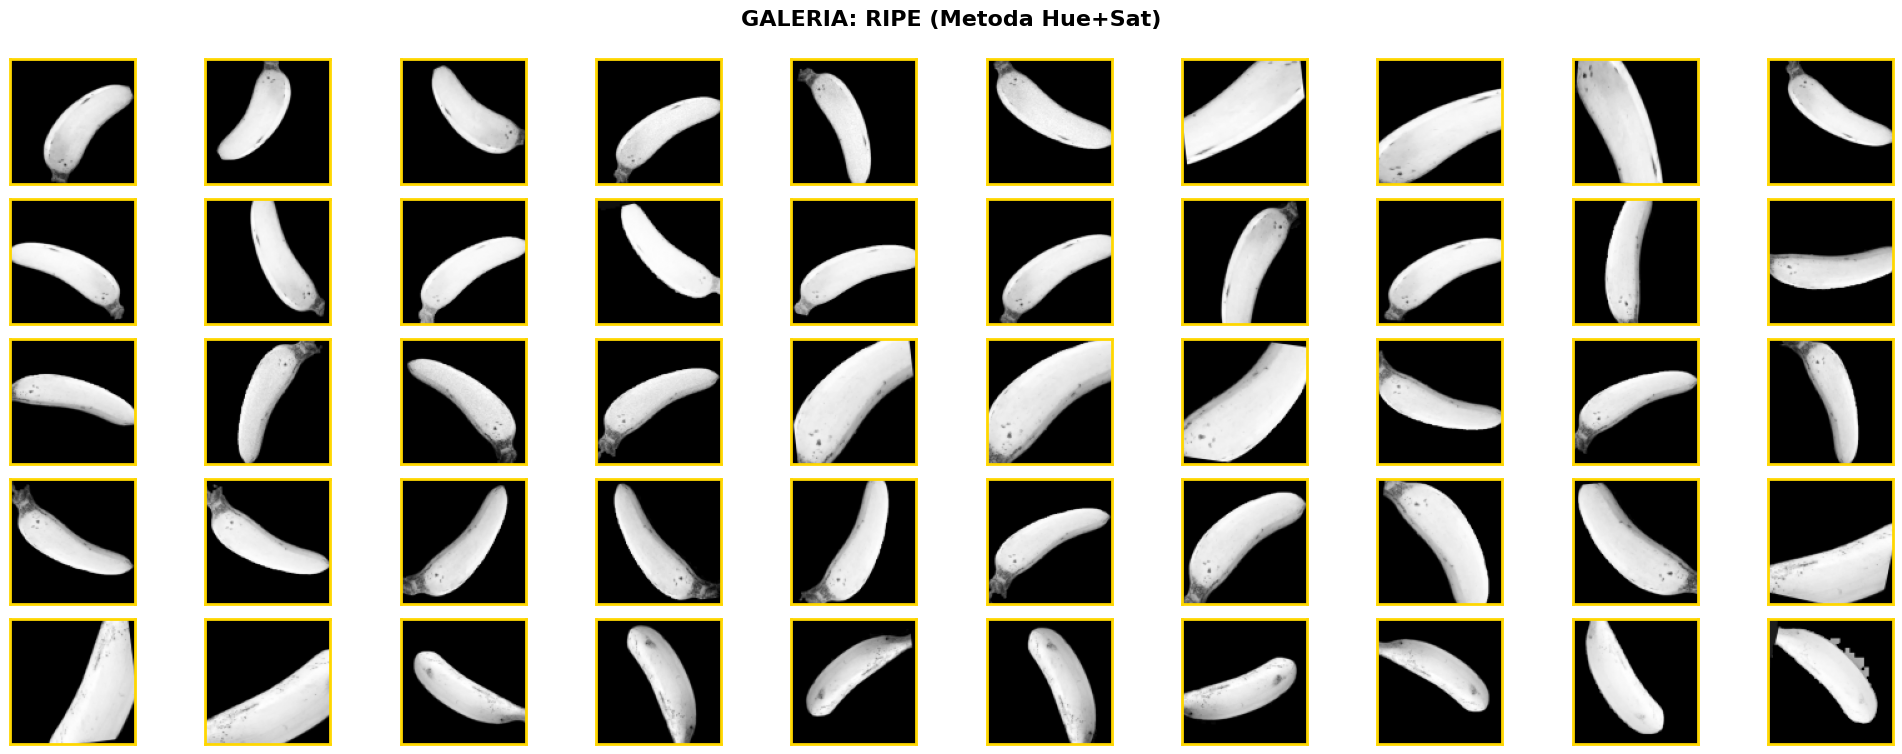


KATEGORIA: OVERRIPE
   -> train/overripe: 2349 plików...
   -> test/overripe: 113 plików...
   -> valid/overripe: 229 plików...
Zakończono OVERRIPE.
💾 Zapisano dashboard: dashboard_overripe.png


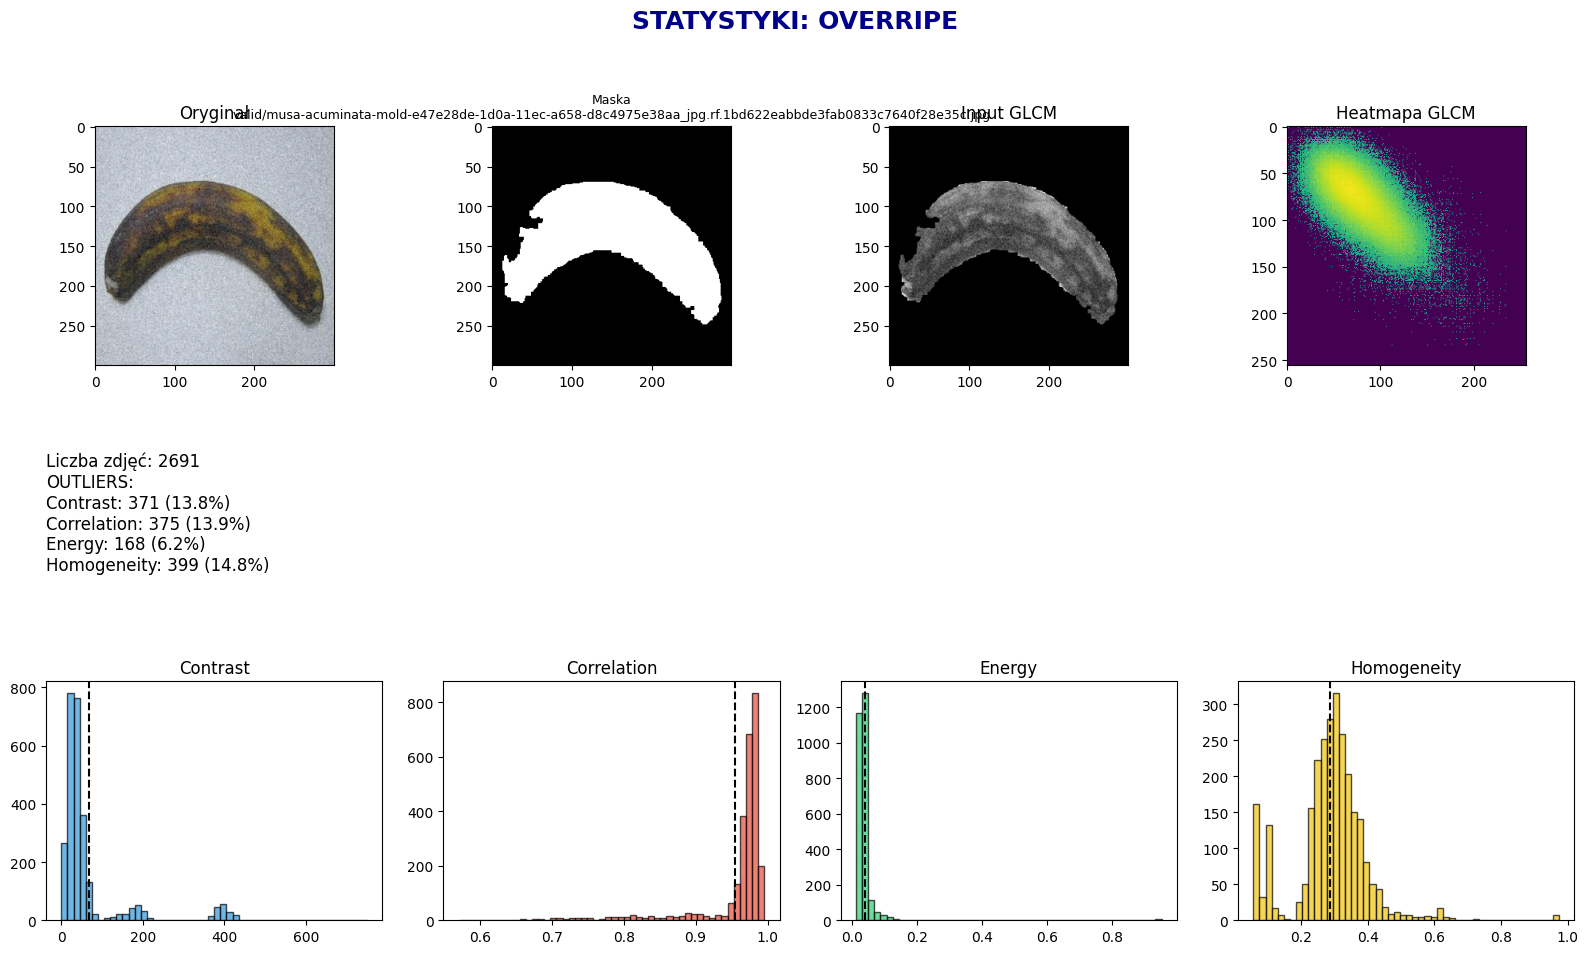

💾 Zapisano galerię: galeria_masek_overripe.png


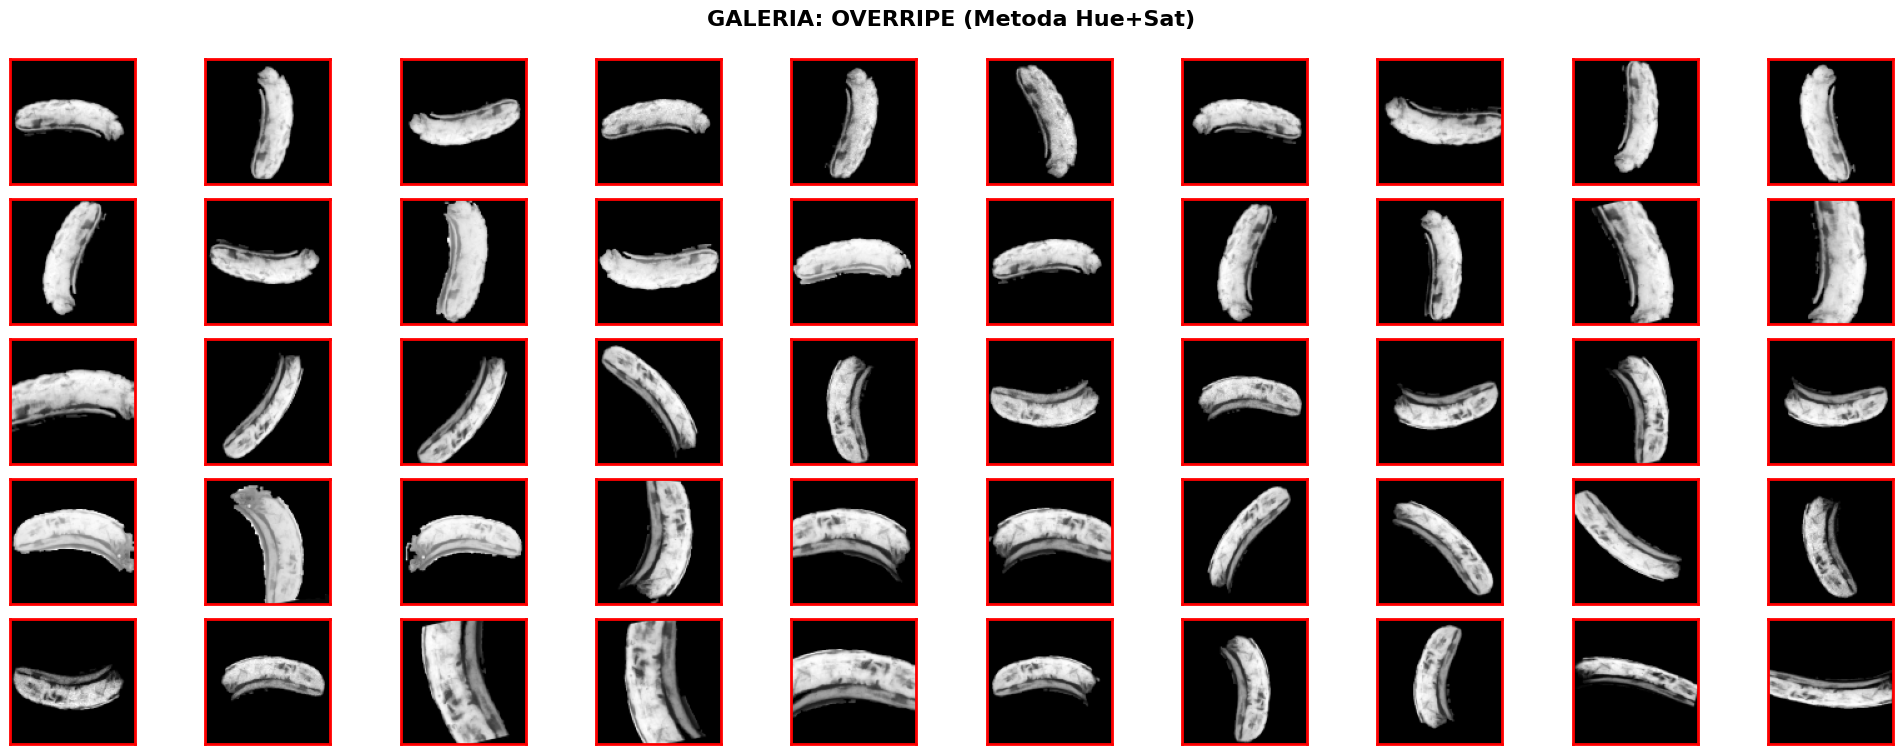


📊 Generowanie zestawienia Z OUTLIERAMI...
💾 Zapisano podsumowanie: podsumowanie_outliers.png


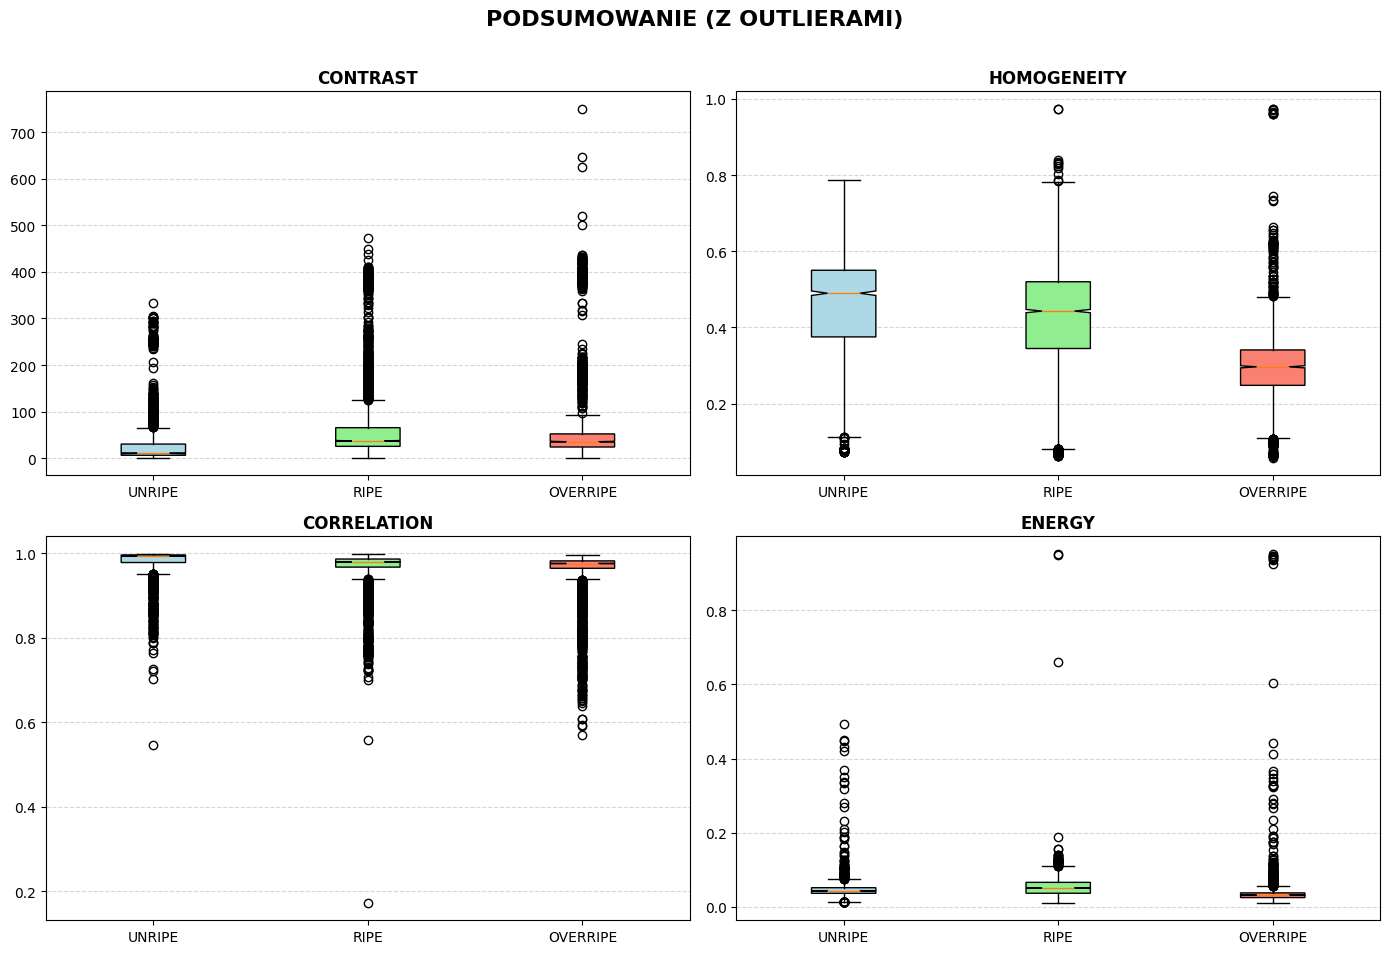


📊 Generowanie zestawienia BEZ OUTLIERÓW...
💾 Zapisano podsumowanie: podsumowanie_clean.png


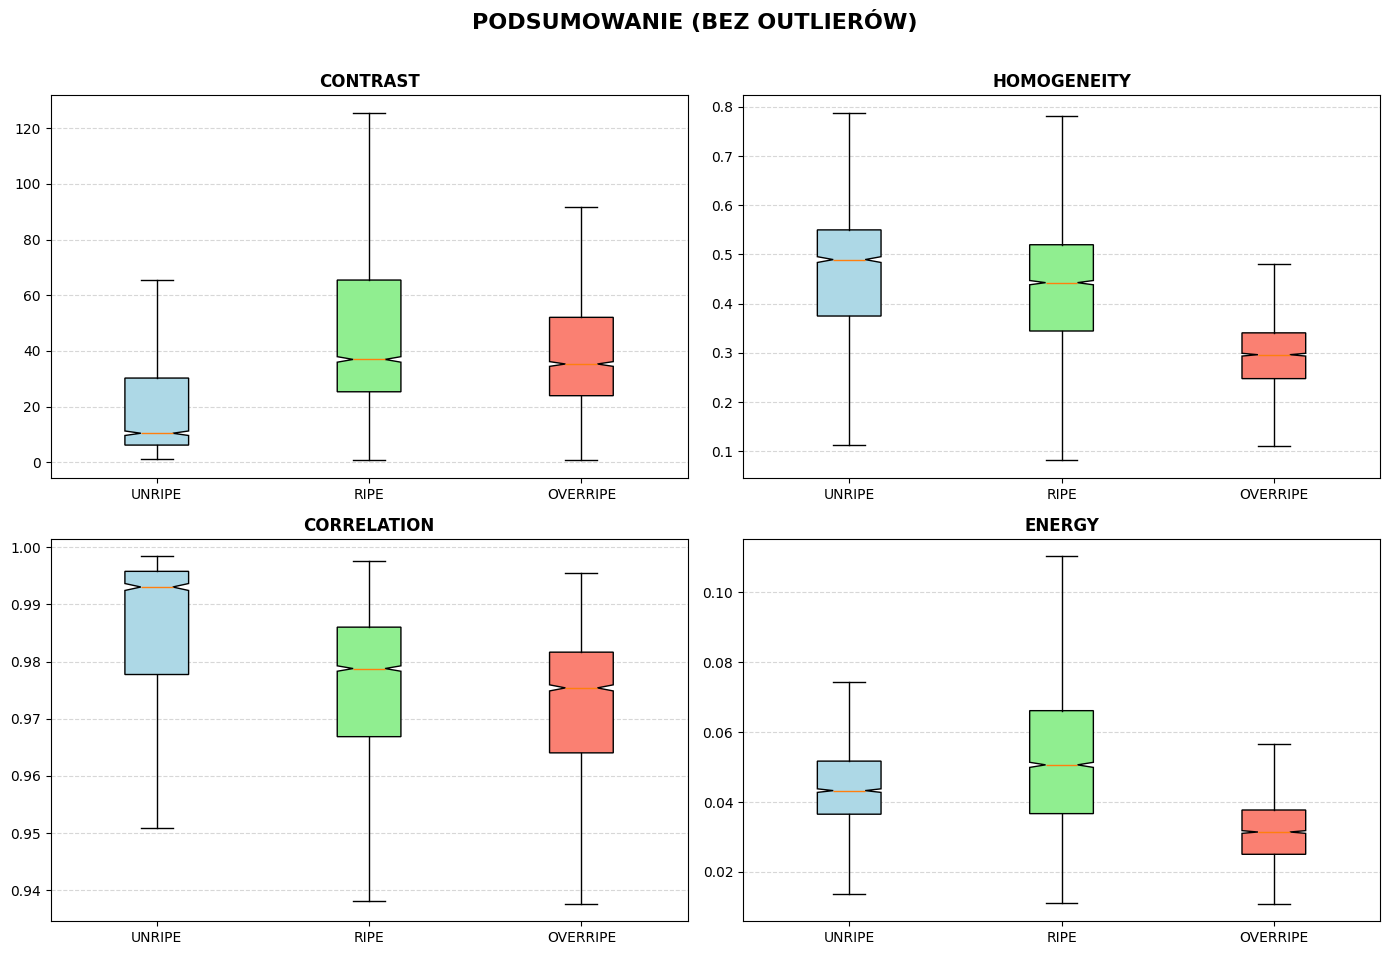


Wszystkie pliki zostały zapisane w folderze 'wyniki'.


In [41]:
aggregated_data = {cat: {m: [] for m in ['Contrast', 'Correlation', 'Energy', 'Homogeneity']} for cat in CATEGORIES}

if BASE_PATH:
    for category in CATEGORIES:
        print(f"\nKATEGORIA: {category.upper()}")

        category_stats = {m: [] for m in ['Contrast', 'Correlation', 'Energy', 'Homogeneity']}
        sample_vis_data = None
        gallery_thumbnails = []
        total_processed = 0

        for split in SPLITS:
            folder = os.path.join(BASE_PATH, split, category)
            if not os.path.exists(folder): continue

            files = sorted([f for f in os.listdir(folder) if f.lower().endswith(('.jpg', '.png'))])
            count = len(files)
            if count == 0: continue

            sample_idx = random.randint(0, count-1)
            print(f"   -> {split}/{category}: {count} plików...")

            for i, fname in enumerate(files):
                img_path = os.path.join(folder, fname)
                img = cv2.imread(img_path)
                if img is None: continue

                mask = get_mask_kmeans_hs(img)
                if mask is None: continue

                feats, masked_gray, viz = calculate_features(img, mask)
                if feats is None: continue

                for k, v in feats.items():
                    category_stats[k].append(v)

                total_processed += 1

                if len(gallery_thumbnails) < VIS_LIMIT:
                    thumb = cv2.resize(masked_gray, (100, 100), interpolation=cv2.INTER_AREA)
                    gallery_thumbnails.append(thumb)

                if sample_vis_data is None or i == sample_idx:
                    img_s = cv2.resize(img, (300, 300))
                    mask_s = cv2.resize(mask, (300, 300), interpolation=cv2.INTER_NEAREST)
                    masked_s = cv2.resize(masked_gray, (300, 300))
                    info = f"{split}/{fname}"
                    sample_vis_data = (img_s, mask_s, masked_s, viz, info)

        aggregated_data[category] = category_stats

        print(f"Zakończono {category.upper()}.")
        plot_category_dashboard(category, category_stats, sample_vis_data)
        plot_mask_gallery(category, gallery_thumbnails)

    plot_final_comparison(aggregated_data, show_outliers=True)
    plot_final_comparison(aggregated_data, show_outliers=False)
    print("\nWszystkie pliki zostały zapisane w folderze 'wyniki'.")
else:
    print("Nie zdefiniowano BASE_PATH.")

### 8. Podsumowanie
* UNRIPE (Niedojrzałe)
Kategoria ta obejmuje 2174 zdjęcia charakteryzujące się jednolitą, zieloną skórką o wysokiej gładkości. Analiza GLCM wykazuje najniższy poziom kontrastu (ok. 7.0) oraz najwyższą korelację (0.994), co potwierdza brak przebarwień i plam na powierzchni owoców. Heatmapa macierzy jest silnie skupiona wzdłuż przekątnej, co matematycznie definiuje teksturę jako bardzo przewidywalną i spójną


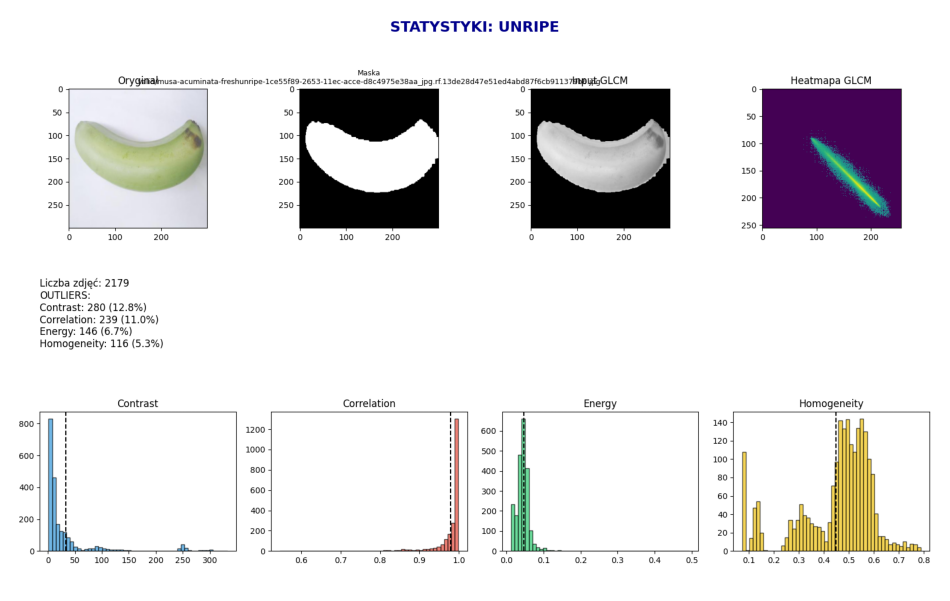

In [42]:
img = cv2.imread(f"wyniki/dashboard_unripe.png")
plt.figure(figsize=(12, 8))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()


* RIPE (Dojrzałe)
Klasa ta jest najliczniejsza (4015 zdjęć) i reprezentuje stadium pełnej dojrzałości z dominującą żółtą barwą. W porównaniu do owoców zielonych, odnotowano gwałtowny wzrost kontrastu (do poziomu 66.8), co wynika z większego zróżnicowania jasności i cieniowania na skórce. Parametr energii jest tutaj najwyższy (0.072), co świadczy o silnej dominacji określonego poziomu jasności w tej fazie.


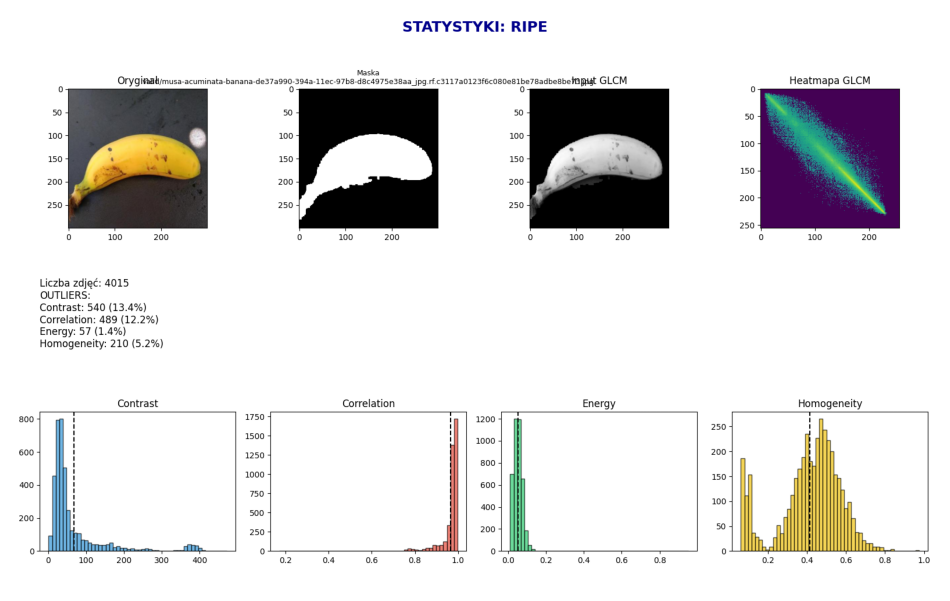

In [43]:
img = cv2.imread(f"wyniki/dashboard_ripe.png")
plt.figure(figsize=(12, 8))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()


* OVERRIPE (Przejrzałe)
Analiza 2691 zdjęć z tej grupy wykazuje postępującą degradację skórki, widoczną jako liczne ciemne plamy i przebarwienia. Cechą charakterystyczną jest najniższa jednorodność (Homogeneity: 0.27) oraz najniższa energia (0.030). Heatmapa GLCM jest najbardziej rozproszona spośród wszystkich klas, co potwierdza matematycznie wysoką zmienność tekstury. Wysoki odsetek outlierów dla jednorodności (14.9%) sugeruje dużą rozpiętość stopnia degradacji owoców wewnątrz tej kategorii.

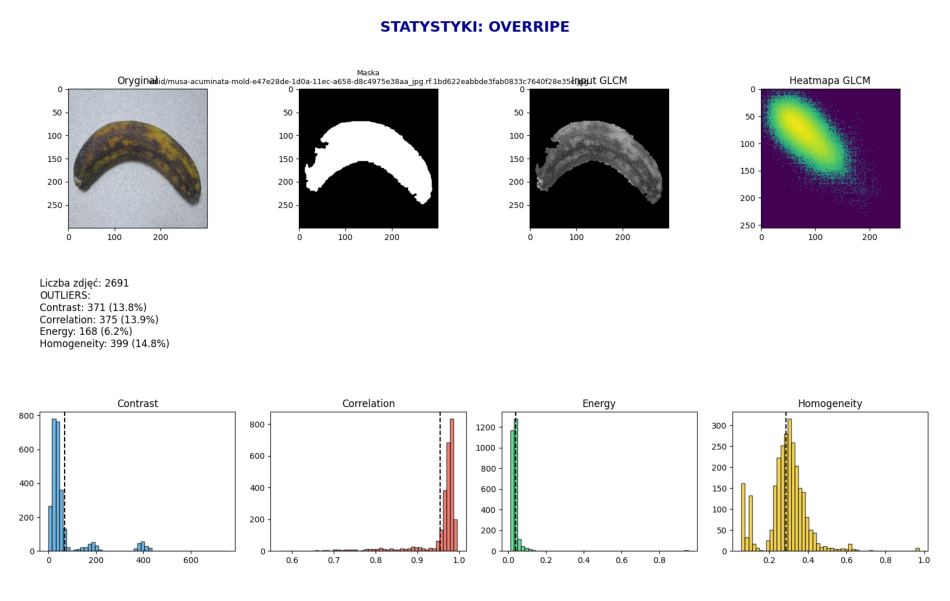

In [44]:
img = cv2.imread(f"wyniki/dashboard_overripe.png")
plt.figure(figsize=(12, 8))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()